# 销售数据分析报告

本笔记本使用模块化方法分析 Excel 中的销售数据，包含数据探索、业务指标计算和可视化展示。

## 目录

1. [环境准备](#环境准备)
2. [数据概览](#数据概览)
3. [数据字典](#数据字典)
4. [核心业务指标](#核心业务指标)
5. [销售分析](#销售分析)
   - [区域销售分析](#区域销售分析)
   - [产品分析](#产品分析)
   - [客户分析](#客户分析)
   - [时间趋势分析](#时间趋势分析)
6. [产品类别分析](#产品类别分析)

## 环境准备

导入必要的库和自定义模块。

In [7]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns

# 导入自定义模块
from data_loader import SalesDataLoader
from business_calc import SalesMetricsCalculator

# 设置中文字体 - 优先使用 macOS 系统可用的中文字体
# 按优先级排序：PingFang(苹方) > Hiragino(黑体 - 简) > Heiti(黑体) > Songti(宋体)
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Hiragino Sans GB', 'Heiti SC', 'Songti SC', 'STFangsong', 'Microsoft YaHei', 'SimHei', 'WenQuanYi Micro Hei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# 设置 seaborn 样式
sns.set_style('whitegrid')

# 定义配色方案
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'success': '#2ECC71',
    'warning': '#E74C3C',
    'palette': ['#2E86AB', '#A23B72', '#F18F01', '#2ECC71', '#E74C3C', '#8E44AD', '#1ABC9C', '#F39C12']
}

print("环境准备完成！")

环境准备完成！


## 数据概览

加载数据并查看基本信息。

In [8]:
# 初始化数据加载器
excel_path = '../datas/sales_data.xlsx'
loader = SalesDataLoader(excel_path)

# 加载所有数据
data = loader.load_all()

# 获取数据基本信息
info = loader.get_data_info()

# 显示数据集概览
print("="*50)
print("销售数据集概览")
print("="*50)
for key, value in info.items():
    print(f"{key}: {value}")

销售数据集概览
订单总数: 200
唯一客户数: 15
唯一产品数: 10
数据时间范围: 2025-01-01 至 2025-06-29
销售区域数: 6
总销售额: ¥291,717.65


In [9]:
# 初始化业务计算器
calculator = SalesMetricsCalculator(
    orders=data['orders'],
    products=data['products'],
    customers=data['customers'],
    targets=data['targets']
)

print("数据加载完成！")
print(f"\n可用工作表：{loader.available_sheets}")

数据加载完成！

可用工作表：['订单明细', '产品信息', '客户信息', '销售目标']


## 数据字典

详细描述各数据表的字段含义。

In [10]:
from IPython.display import Markdown, display

# 获取数据字典
data_dict = loader.get_data_dictionary()

for sheet_name, fields in data_dict.items():
    display(Markdown(f"### 📊 {sheet_name}"))
    
    # 创建字段说明表格
    dict_df = pd.DataFrame({
        '字段名': list(fields.keys()),
        '说明': list(fields.values())
    })
    display(dict_df.style.set_properties(**{'text-align': 'left'})
            .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))
    print()

### 📊 订单明细

,字段名,说明
0,order_id,订单 ID，唯一标识每个订单
1,order_date,订单日期，格式为 YYYY-MM-DD
2,customer_id,客户 ID，关联客户信息表
3,product_id,产品 ID，关联产品信息表
4,quantity,购买数量
5,unit_price,商品单价（元）
6,subtotal,小计金额 = quantity * unit_price
7,discount_rate,折扣率，0-1 之间的小数
8,discount_amount,折扣金额 = subtotal * discount_rate
9,total_amount,最终金额 = subtotal - discount_amount


### 📊 产品信息

,字段名,说明
0,product_id,产品 ID，唯一标识每个产品
1,product_name,产品名称
2,category,产品类别
3,cost_price,成本价格（元）
4,sell_price,销售价格（元）


### 📊 客户信息

,字段名,说明
0,customer_id,客户 ID，唯一标识每个客户
1,customer_name,客户姓名
2,city,所在城市
3,customer_type,客户类型：企业客户/个人客户


### 📊 销售目标

,字段名,说明
0,salesperson_id,销售人员 ID
1,salesperson_name,销售人员姓名
2,target_jan,1 月销售目标（元）
3,target_feb,2 月销售目标（元）
4,target_mar,3 月销售目标（元）
5,target_apr,4 月销售目标（元）
6,target_may,5 月销售目标（元）
7,target_jun,6 月销售目标（元）


## 核心业务指标

展示关键业务指标（KPI）。

In [11]:
# 获取核心指标
metrics = calculator.get_summary_metrics()

# 创建指标展示表格
metrics_df = pd.DataFrame({
    '指标': ['总销售额', '总订单数', '活跃客户数', '销售产品数', '毛利润', '整体毛利率', '平均订单金额', '客单价'],
    '数值': [
        f"¥{metrics['总销售额']:,.2f}",
        f"{metrics['总订单数']:,}",
        f"{metrics['活跃客户数']:,}",
        f"{metrics['销售产品数']:,}",
        f"¥{metrics['毛利润']:,.2f}",
        f"{metrics['整体毛利率']:.2f}%",
        f"¥{metrics['平均订单金额']:,.2f}",
        f"¥{metrics['客单价']:,.2f}"
    ]
})

display(metrics_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([{'selector': 'th', 'props': [('background-color', COLORS['primary']), ('color', 'white')]}]))

,指标,数值
0,总销售额,"¥291,717.65"
1,总订单数,200
2,活跃客户数,15
3,销售产品数,10
4,毛利润,"¥79,312.65"
5,整体毛利率,27.19%
6,平均订单金额,"¥1,458.59"
7,客单价,"¥19,447.84"


## 销售分析

### 区域销售分析

分析各区域的销售表现。

/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/3190524968.py:39: UserWarning: Glyph 21326 (\N{CJK UNIFIED IDEOGRAPH-534E}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/3190524968.py:39: UserWarning: Glyph 19996 (\N{CJK UNIFIED IDEOGRAPH-4E1C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/3190524968.py:39: UserWarning: Glyph 21335 (\N{CJK UNIFIED IDEOGRAPH-5357}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/3190524968.py:39: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/3190524968.py:39: UserWarning: Glyph 35199 (\N{CJK UNIFIED IDEOGRAPH-897F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/i

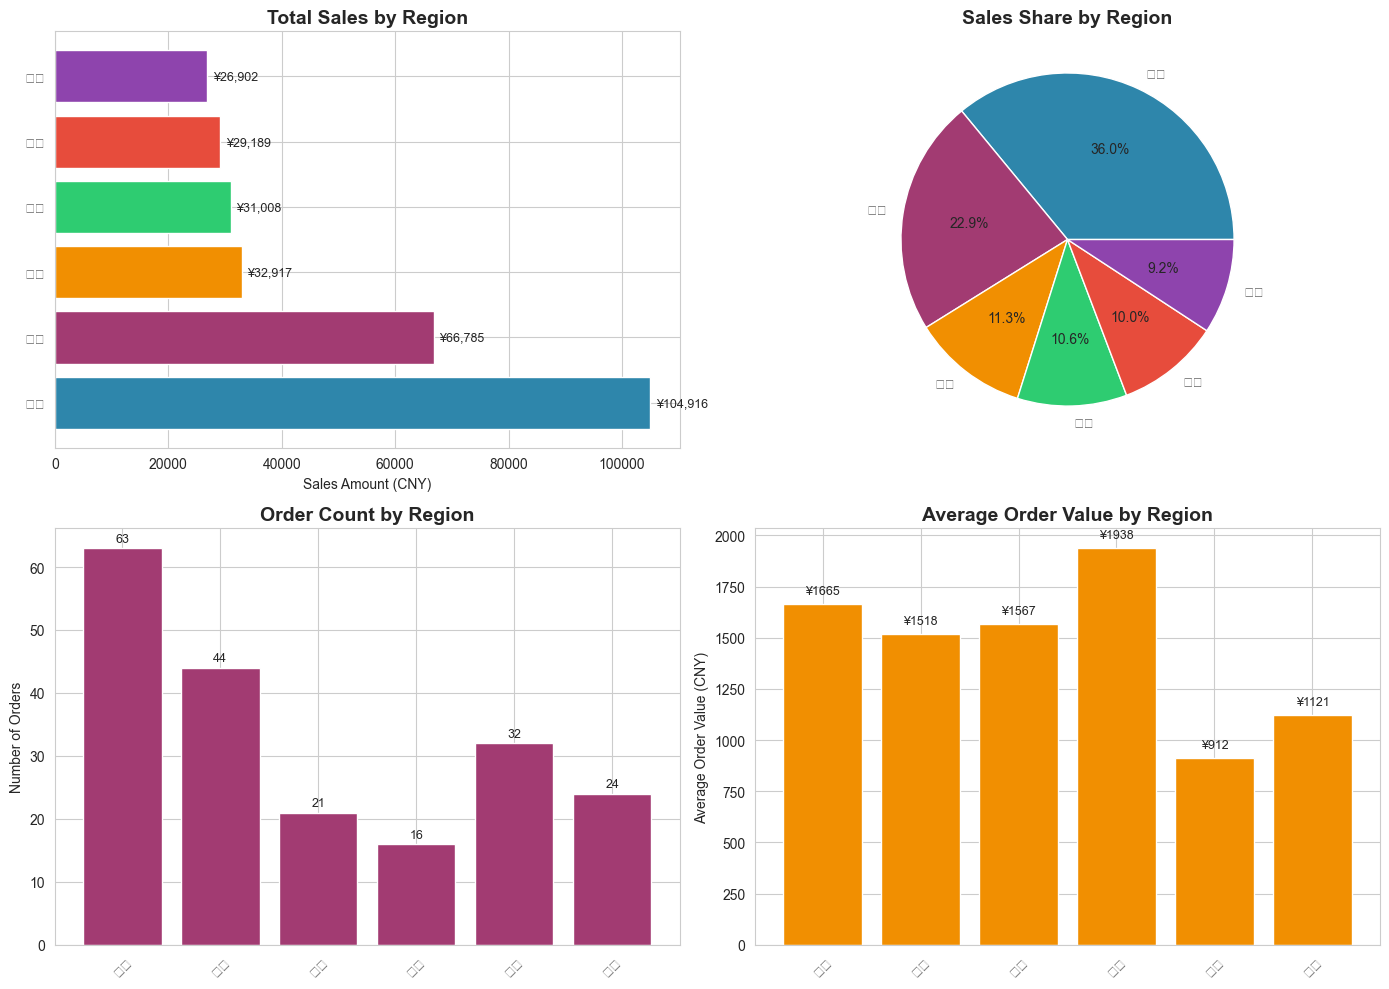

区域销售详细数据：


,region,总销售额,订单数,平均订单金额,销售占比
0,华东,"¥104,916.15",63,"¥1,665.34",35.96%
1,华南,"¥66,785.05",44,"¥1,517.84",22.89%
2,华中,"¥32,917.05",21,"¥1,567.48",11.28%
3,西北,"¥31,008.00",16,"¥1,938.00",10.63%
4,华北,"¥29,189.15",32,¥912.16,10.01%
5,西南,"¥26,902.25",24,"¥1,120.93",9.22%


In [12]:
# 获取区域销售数据
region_sales = calculator.get_regional_sales()

# 创建可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 区域销售额柱状图
ax1 = axes[0, 0]
bars1 = ax1.barh(region_sales['region'], region_sales['总销售额'], color=COLORS['palette'][:len(region_sales)])
ax1.set_xlabel('Sales Amount (CNY)')
ax1.set_title('Total Sales by Region', fontsize=14, fontweight='bold')
for bar, val in zip(bars1, region_sales['总销售额']):
    ax1.text(val + 1000, bar.get_y() + bar.get_height()/2, f'¥{val:,.0f}', va='center', fontsize=9)

# 2. 区域销售占比饼图
ax2 = axes[0, 1]
wedges, texts, autotexts = ax2.pie(region_sales['总销售额'], labels=region_sales['region'],
                                     autopct='%1.1f%%', colors=COLORS['palette'][:len(region_sales)])
ax2.set_title('Sales Share by Region', fontsize=14, fontweight='bold')

# 3. 区域订单数分布
ax3 = axes[1, 0]
bars3 = ax3.bar(region_sales['region'], region_sales['订单数'], color=COLORS['secondary'])
ax3.set_ylabel('Number of Orders')
ax3.set_title('Order Count by Region', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, region_sales['订单数']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val}', ha='center', fontsize=9)

# 4. 区域平均订单金额
ax4 = axes[1, 1]
bars4 = ax4.bar(region_sales['region'], region_sales['平均订单金额'], color=COLORS['accent'])
ax4.set_ylabel('Average Order Value (CNY)')
ax4.set_title('Average Order Value by Region', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
for bar, val in zip(bars4, region_sales['平均订单金额']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'¥{val:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 显示详细数据
print("区域销售详细数据：")
display(region_sales.style.format({
    '总销售额': '¥{:,.2f}',
    '平均订单金额': '¥{:,.2f}',
    '销售占比': '{:.2f}%'
}).background_gradient(subset=['总销售额'], cmap='YlOrRd'))

### 产品分析

分析各产品的销售表现和盈利能力。

/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/2383558488.py:47: UserWarning: Glyph 31508 (\N{CJK UNIFIED IDEOGRAPH-7B14}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/2383558488.py:47: UserWarning: Glyph 35760 (\N{CJK UNIFIED IDEOGRAPH-8BB0}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/2383558488.py:47: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/2383558488.py:47: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/2383558488.py:47: UserWarning: Glyph 33041 (\N{CJK UNIFIED IDEOGRAPH-8111}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/i

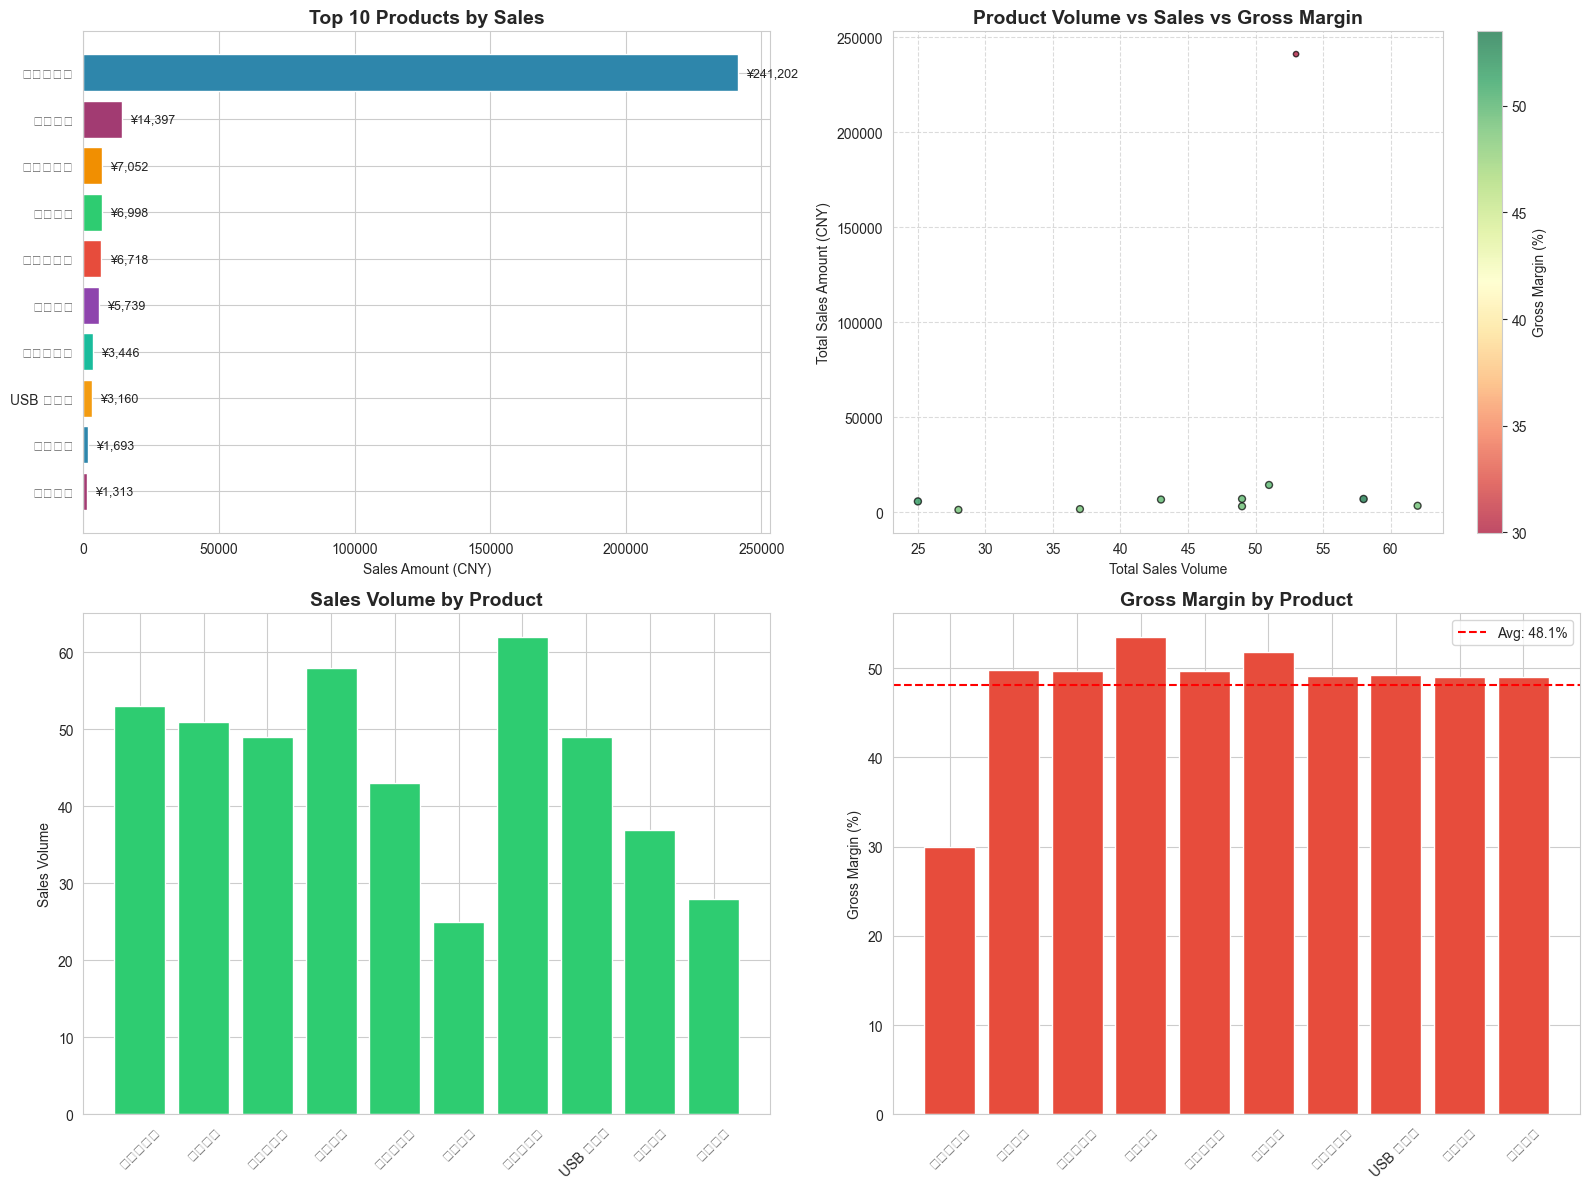

,product_name,总销量,总销售额,平均订单金额,订单数,毛利率
0,笔记本电脑,53,"¥241,201.75","¥10,487.03",23,29.99%
1,机械键盘,51,"¥14,396.85",¥654.40,22,49.83%
2,显示器支架,49,"¥7,051.65",¥282.07,25,49.69%
3,移动电源,58,"¥6,998.25",¥304.27,23,53.49%
4,网络摄像头,43,"¥6,717.75",¥373.21,18,49.70%
5,蓝牙耳机,25,"¥5,739.45",¥478.29,12,51.81%
6,桌面收纳盒,62,"¥3,445.60",¥118.81,29,49.15%
7,USB 集线器,49,"¥3,160.20",¥150.49,21,49.28%
8,无线鼠标,37,"¥1,692.95",¥130.23,13,48.98%
9,手机支架,28,"¥1,313.20",¥93.80,14,48.98%


In [13]:
# 获取产品销售数据
product_sales = calculator.get_product_sales()

# 创建可视化
fig = plt.figure(figsize=(16, 12))

# 1. 产品销售额排行（TOP 10）
ax1 = plt.subplot(2, 2, 1)
top10 = product_sales.head(10)
bars1 = ax1.barh(range(len(top10)), top10['总销售额'], color=COLORS['palette'][:len(top10)])
ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels(top10['product_name'])
ax1.set_xlabel('Sales Amount (CNY)')
ax1.set_title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars1, top10['总销售额']):
    ax1.text(val + 3000, bar.get_y() + bar.get_height()/2, f'¥{val:,.0f}', va='center', fontsize=9)

# 2. 产品销量 vs 销售额散点图
ax2 = plt.subplot(2, 2, 2)
scatter = ax2.scatter(product_sales['总销量'], product_sales['总销售额'],
                      s=product_sales['毛利率']/2, c=product_sales['毛利率'],
                      cmap='RdYlGn', alpha=0.7, edgecolors='black')
ax2.set_xlabel('Total Sales Volume')
ax2.set_ylabel('Total Sales Amount (CNY)')
ax2.set_title('Product Volume vs Sales vs Gross Margin', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label('Gross Margin (%)')

# 3. 产品销量分布
ax3 = plt.subplot(2, 2, 3)
ax3.bar(product_sales['product_name'], product_sales['总销量'], color=COLORS['success'])
ax3.set_ylabel('Sales Volume')
ax3.set_title('Sales Volume by Product', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# 4. 产品毛利率对比
ax4 = plt.subplot(2, 2, 4)
bars4 = ax4.bar(product_sales['product_name'], product_sales['毛利率'], color=COLORS['warning'])
ax4.set_ylabel('Gross Margin (%)')
ax4.set_title('Gross Margin by Product', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.axhline(y=product_sales['毛利率'].mean(), color='r', linestyle='--', label=f"Avg: {product_sales['毛利率'].mean():.1f}%")
ax4.legend()

plt.tight_layout()
plt.show()

# 显示详细数据
display_columns = ['product_name', '总销量', '总销售额', '平均订单金额', '订单数', '毛利率']
display(product_sales[display_columns].style.format({
    '总销售额': '¥{:,.2f}',
    '平均订单金额': '¥{:,.2f}',
    '毛利率': '{:.2f}%'
}).background_gradient(subset=['总销售额'], cmap='Blues'))

### 客户分析

分析不同客户类型的消费行为。

/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/2764052519.py:34: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/2764052519.py:34: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/2764052519.py:34: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/2764052519.py:34: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/2764052519.py:34: UserWarning: Glyph 20225 (\N{CJK UNIFIED IDEOGRAPH-4F01}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/i

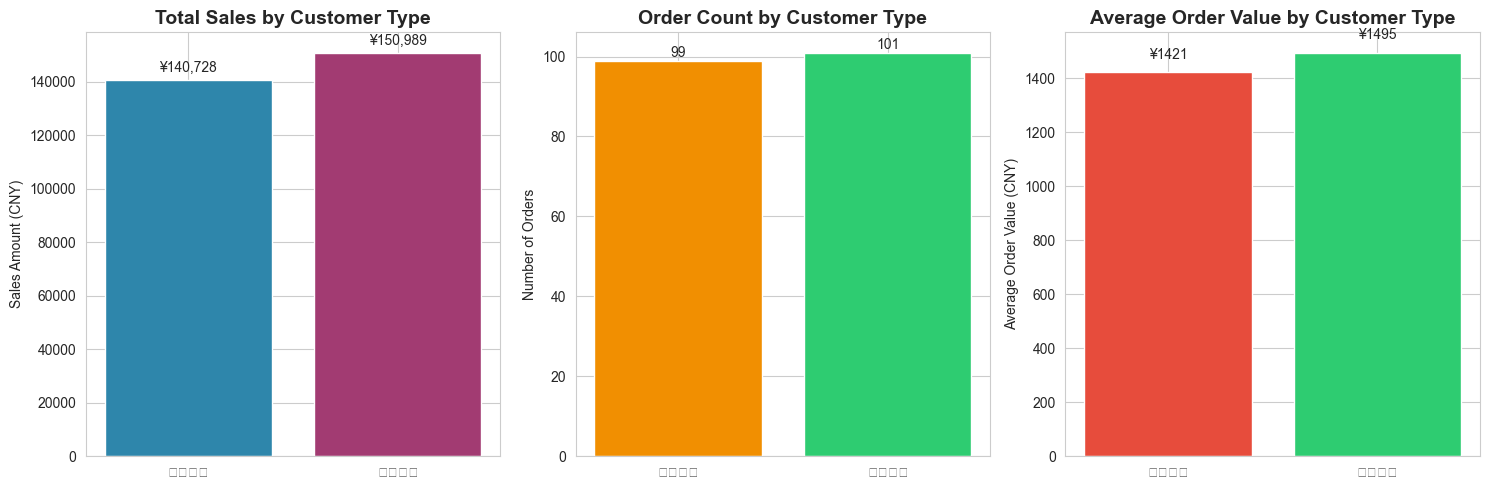

客户类型分析详细数据：


,customer_type,总销售额,平均订单金额,订单数,标准差,销售占比
0,个人客户,"¥140,728.40","¥1,421.50",99,3558.85,48.24%
1,企业客户,"¥150,989.25","¥1,494.94",101,4355.59,51.76%


In [14]:
# 获取客户类型分析
customer_analysis = calculator.get_customer_type_analysis()

# 创建可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. 客户类型销售额对比
ax1 = axes[0]
bars1 = ax1.bar(customer_analysis['customer_type'], customer_analysis['总销售额'],
                color=[COLORS['primary'], COLORS['secondary']])
ax1.set_ylabel('Sales Amount (CNY)')
ax1.set_title('Total Sales by Customer Type', fontsize=14, fontweight='bold')
for bar, val in zip(bars1, customer_analysis['总销售额']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000, f'¥{val:,.0f}', ha='center', fontsize=10)

# 2. 客户类型订单数对比
ax2 = axes[1]
bars2 = ax2.bar(customer_analysis['customer_type'], customer_analysis['订单数'],
                color=[COLORS['accent'], COLORS['success']])
ax2.set_ylabel('Number of Orders')
ax2.set_title('Order Count by Customer Type', fontsize=14, fontweight='bold')
for bar, val in zip(bars2, customer_analysis['订单数']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val}', ha='center', fontsize=10)

# 3. 客户类型平均订单金额对比
ax3 = axes[2]
bars3 = ax3.bar(customer_analysis['customer_type'], customer_analysis['平均订单金额'],
                color=[COLORS['warning'], COLORS['success']])
ax3.set_ylabel('Average Order Value (CNY)')
ax3.set_title('Average Order Value by Customer Type', fontsize=14, fontweight='bold')
for bar, val in zip(bars3, customer_analysis['平均订单金额']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'¥{val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 显示详细数据
print("客户类型分析详细数据：")
display(customer_analysis.style.format({
    '总销售额': '¥{:,.2f}',
    '平均订单金额': '¥{:,.2f}',
    '销售占比': '{:.2f}%',
    '标准差': '{:.2f}'
}).background_gradient(subset=['总销售额'], cmap='PuBu'))

### 时间趋势分析

分析销售的时间趋势。

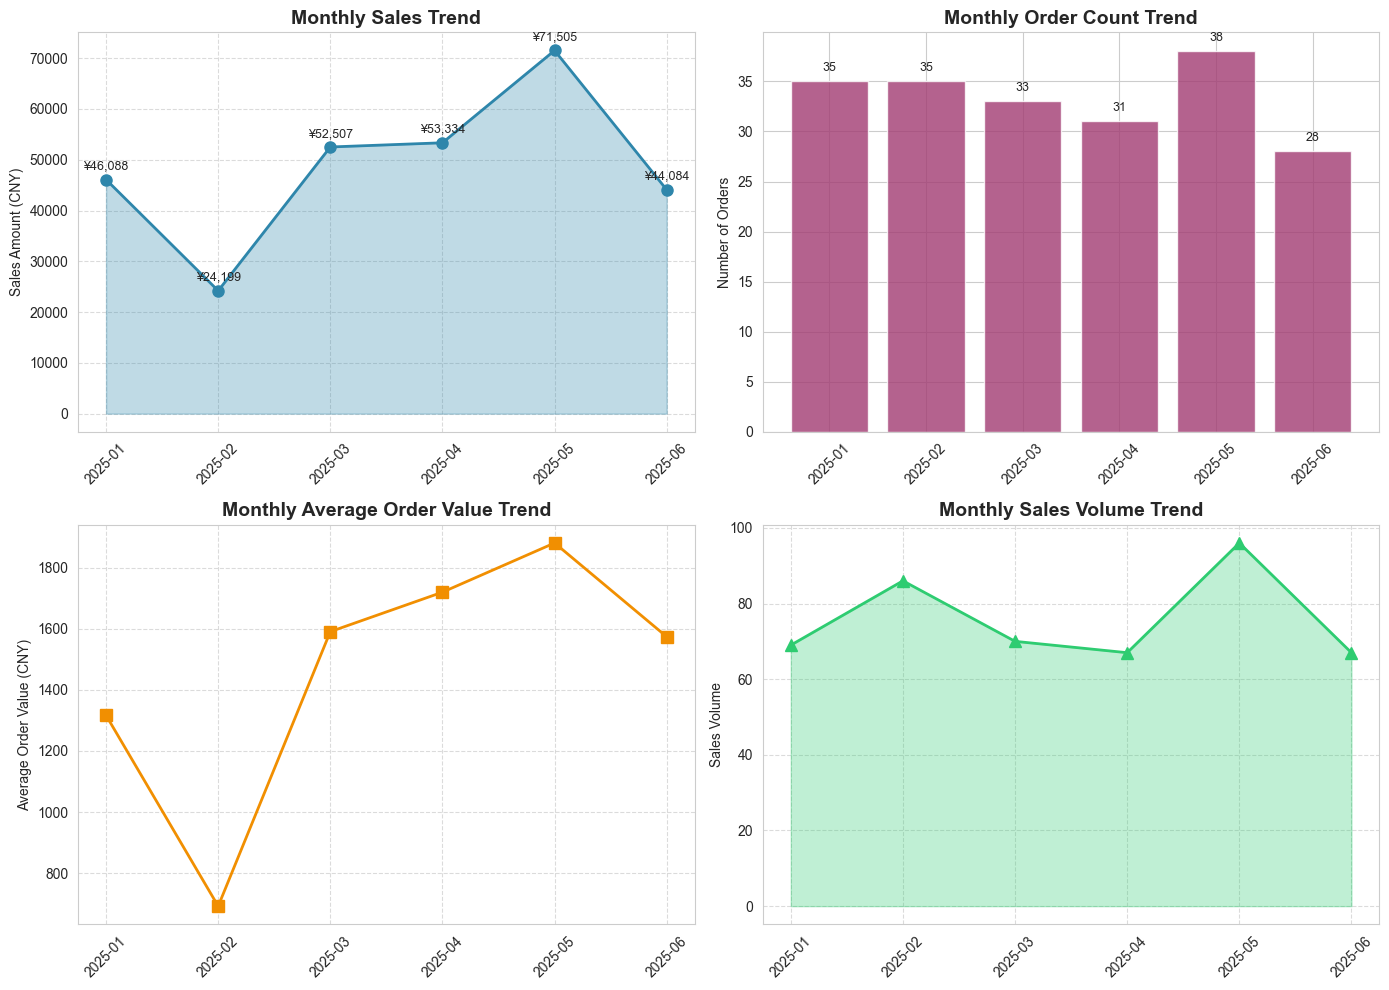

月度销售详细数据：


,month,销售额,平均订单金额,订单数,总销量
0,2025-01,"¥46,088.45","¥1,316.81",35,69
1,2025-02,"¥24,199.15",¥691.40,35,86
2,2025-03,"¥52,507.00","¥1,591.12",33,70
3,2025-04,"¥53,334.00","¥1,720.45",31,67
4,2025-05,"¥71,505.00","¥1,881.71",38,96
5,2025-06,"¥44,084.05","¥1,574.43",28,67


In [15]:
# 获取月度销售趋势
monthly_sales = calculator.get_monthly_trend()

# 创建可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 月度销售额趋势
ax1 = axes[0, 0]
ax1.plot(monthly_sales['month'], monthly_sales['销售额'], marker='o', linewidth=2,
         markersize=8, color=COLORS['primary'])
ax1.fill_between(monthly_sales['month'], monthly_sales['销售额'], alpha=0.3, color=COLORS['primary'])
ax1.set_ylabel('Sales Amount (CNY)')
ax1.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.7)
for x, y in zip(monthly_sales['month'], monthly_sales['销售额']):
    ax1.text(x, y + 2000, f'¥{y:,.0f}', ha='center', fontsize=9)

# 2. 月度订单数趋势
ax2 = axes[0, 1]
ax2.bar(monthly_sales['month'], monthly_sales['订单数'], color=COLORS['secondary'], alpha=0.8)
ax2.set_ylabel('Number of Orders')
ax2.set_title('Monthly Order Count Trend', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
for x, y in zip(monthly_sales['month'], monthly_sales['订单数']):
    ax2.text(x, y + 1, f'{y}', ha='center', fontsize=9)

# 3. 月度平均订单金额趋势
ax3 = axes[1, 0]
ax3.plot(monthly_sales['month'], monthly_sales['平均订单金额'], marker='s', linewidth=2,
         markersize=8, color=COLORS['accent'])
ax3.set_ylabel('Average Order Value (CNY)')
ax3.set_title('Monthly Average Order Value Trend', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, linestyle='--', alpha=0.7)

# 4. 月度销量趋势
ax4 = axes[1, 1]
ax4.plot(monthly_sales['month'], monthly_sales['总销量'], marker='^', linewidth=2,
         markersize=8, color=COLORS['success'])
ax4.fill_between(monthly_sales['month'], monthly_sales['总销量'], alpha=0.3, color=COLORS['success'])
ax4.set_ylabel('Sales Volume')
ax4.set_title('Monthly Sales Volume Trend', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 显示月度销售数据
print("月度销售详细数据：")
display(monthly_sales.style.format({
    '销售额': '¥{:,.2f}',
    '平均订单金额': '¥{:,.2f}'
}))

## 产品类别分析

分析不同产品类别的表现。

/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/3051721972.py:30: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/3051721972.py:30: UserWarning: Glyph 33041 (\N{CJK UNIFIED IDEOGRAPH-8111}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/3051721972.py:30: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/3051721972.py:30: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/ipykernel_58158/3051721972.py:30: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/288tn6h50rg4zskgnxdd_n240000gn/T/i

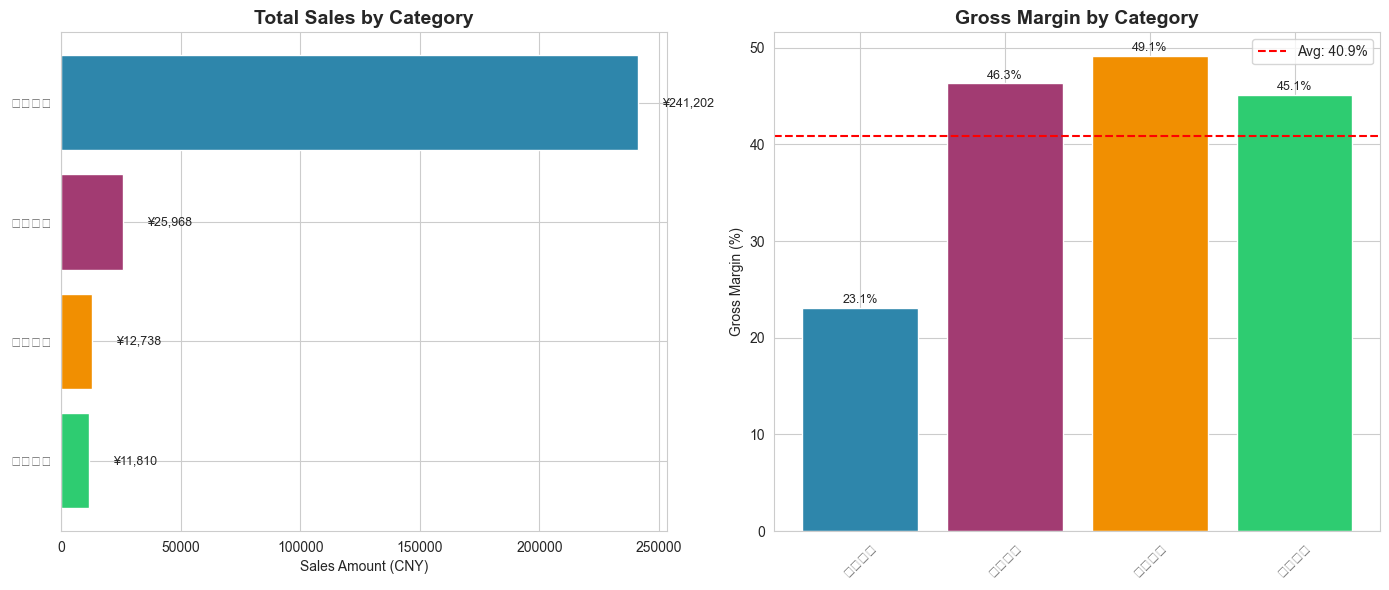

产品类别分析详细数据：


,category,总销量,总销售额,订单数,毛利润,毛利率
0,电脑整机,53,"¥241,201.75",23,"¥55,701.75",23.09%
1,电脑配件,180,"¥25,967.75",74,"¥12,022.75",46.30%
2,数码配件,83,"¥12,737.70",35,"¥6,257.70",49.13%
3,办公周边,139,"¥11,810.45",68,"¥5,330.45",45.13%


In [16]:
# 获取类别分析数据
category_analysis = calculator.get_category_performance()

# 创建可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. 各类别销售额对比
ax1 = axes[0]
bars1 = ax1.barh(category_analysis['category'], category_analysis['总销售额'],
                 color=COLORS['palette'][:len(category_analysis)])
ax1.set_xlabel('Sales Amount (CNY)')
ax1.set_title('Total Sales by Category', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars1, category_analysis['总销售额']):
    ax1.text(val + 10000, bar.get_y() + bar.get_height()/2, f'¥{val:,.0f}', va='center', fontsize=9)

# 2. 各类别毛利率对比
ax2 = axes[1]
bars2 = ax2.bar(category_analysis['category'], category_analysis['毛利率'],
                color=COLORS['palette'][:len(category_analysis)])
ax2.set_ylabel('Gross Margin (%)')
ax2.set_title('Gross Margin by Category', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=category_analysis['毛利率'].mean(), color='r', linestyle='--',
            label=f"Avg: {category_analysis['毛利率'].mean():.1f}%")
ax2.legend()
for bar, val in zip(bars2, category_analysis['毛利率']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 显示详细数据
print("产品类别分析详细数据：")
display(category_analysis.style.format({
    '总销售额': '¥{:,.2f}',
    '毛利润': '¥{:,.2f}',
    '毛利率': '{:.2f}%'
}).background_gradient(subset=['总销售额'], cmap='Greens'))

## 总结

本分析报告展示了销售数据的多个维度：

### 关键发现

1. **区域表现**：华东地区销售额最高，占总销售额的重要比例
2. **产品表现**：笔记本电脑是销售额最高的产品
3. **客户类型**：企业客户和个人客户的销售额相对均衡
4. **时间趋势**：5 月份销售额达到峰值

### 建议

- 重点关注华东地区的市场维护
- 对低销量产品考虑促销策略
- 针对企业客户开发更多高价值产品
- 分析销售低谷期的原因并制定对策